In [17]:
%pip install statsmodels
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
  Using cached matplotlib-3.11.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-macosx_10_13_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.0-cp313-cp313-macosx_11_0_arm64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp313-cp313-macosx_10_13_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl (64 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 50.0 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-a

In [13]:
import pandas as pd
import statsmodels.api as sm

# 1. Load your Excel file
df = pd.read_excel('Desktop/Practice/Mod2_Wk7_Forecasting.xlsx')

# 2. Engineer your features using your exact column name
df['Trend'] = range(1, len(df) + 1)

# Notice the exact match here, comma and all:
df['Lagged_Price'] = df['Chocolate Chip Cookies'].shift(1)  

# 3. Clean the rows
features = ['Chocolate Chip Cookies', 'Trend', 'Q1', 'Q2', 'Q3', 'Lagged_Price']
df_clean = df[features].dropna()

# 4. Define your Y (what you want to predict) and X (your predictors)
Y = df_clean['Chocolate Chip Cookies']
X = df_clean[['Trend', 'Q1', 'Q2', 'Q3', 'Lagged_Price']]

# 5. Add the Y-intercept constant
X = sm.add_constant(X)

# 6. Fit the Regression Model
model = sm.OLS(Y, X).fit()

# 7. Print the summary dashboard
print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     Chocolate Chip Cookies   R-squared:                       0.979
Model:                                OLS   Adj. R-squared:                  0.979
Method:                     Least Squares   F-statistic:                     4529.
Date:                    Thu, 02 Jul 2026   Prob (F-statistic):               0.00
Time:                            07:43:56   Log-Likelihood:                 517.34
No. Observations:                     487   AIC:                            -1023.
Df Residuals:                         481   BIC:                            -997.6
Df Model:                               5                                         
Covariance Type:                nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const   

In [14]:
import pandas as pd
import statsmodels.api as sm

# 1. Load your Excel file
df = pd.read_excel('Desktop/Practice/Mod2_Wk7_Forecasting.xlsx')

# 2. Engineer your features using your exact column name
df['Trend'] = range(1, len(df) + 1)

# Notice the exact match here, comma and all:
df['Lagged_Price'] = df['Chocolate Chip Cookies'].shift(1)  

# 3. Clean the rows
features = ['Chocolate Chip Cookies', 'Trend', 'Q1', 'Q2', 'Q3', 'Lagged_Price']
df_clean = df[features].dropna()

# 4. Define your Y (what you want to predict) and X (your predictors)
Y = df_clean['Chocolate Chip Cookies']
X = df_clean[['Trend', 'Q1', 'Q2', 'Q3', 'Lagged_Price']]

# 5. Add the Y-intercept constant
X = sm.add_constant(X)

# 6. Fit the Regression Model
model = sm.OLS(Y, X).fit()

# 7. Print the summary dashboard
# Assuming your model is already fit: model = sm.OLS(Y, X).fit()

print("SUMMARY OUTPUT (Excel Style)")
print("=" * 40)
print("Regression Statistics")
print("-" * 40)

# 1. Format R-Square and Adjusted R-Square as rounded percentages
r_square = f"{model.rsquared * 100:.0f}%"
adj_r_square = f"{model.rsquared_adj * 100:.0f}%"

# 2. Extract the Standard Error of the Regression (Residual Standard Error)
# In statsmodels, taking the square root of the Mean Squared Error of Residuals (mse_resid)
# gives you the exact "Standard Error" metric that Excel calculates.
standard_error = f"${model.mse_resid**0.5:.2f}"

# 3. Total number of data points used
observations = int(model.nobs)

# Print the top Summary Table
print(f"{'R Square':<25} {r_square:>14}")
print(f"{'Adjusted R Square':<25} {adj_r_square:>14}")
print(f"{'Standard Error':<25} {standard_error:>14}")
print(f"{'Observations':<25} {observations:>14}")
print("=" * 40)

print("\nCoefficients Table")
print("-" * 40)
print(f"{'Variable':<25} {'Coefficient':>14}")
print("-" * 40)

# 4. Loop through and format the coefficients to 2 decimal places with a dollar sign
for variable, coefficient in model.params.items():
    # Nicely handle the intercept naming to match Excel's "Intercept"
    display_name = "Intercept" if variable == "const" else variable
    
    print(f"{display_name:<25} ${coefficient:>13.2f}")
print("=" * 40)

SUMMARY OUTPUT (Excel Style)
Regression Statistics
----------------------------------------
R Square                             98%
Adjusted R Square                    98%
Standard Error                     $0.08
Observations                         487

Coefficients Table
----------------------------------------
Variable                     Coefficient
----------------------------------------
Intercept                 $         0.18
Trend                     $         0.00
Q1                        $        -0.03
Q2                        $        -0.01
Q3                        $        -0.03
Lagged_Price              $         0.91


In [15]:
# 1. Define your scenario inputs exactly as you described
inputs = {
    'const': 1,              # Intercept multiplier is always 1
    'Trend': 300,            # Your specific future time period
    'Q1': 0,
    'Q2': 0,
    'Q3': 1,                 # Turning on Q3 dummy variable
    'Lagged_Price': 1.15     # The previous period's price
}

# 2. Extract the coefficients from your trained model
coefficients = model.params

# 3. Replicate Excel's =SUMPRODUCT()
# This loops through your inputs, multiplies them by the matching coefficient, and adds them up
predicted_price = sum(inputs[var] * coefficients[var] for var in inputs)

# 4. Pull the Standard Error dynamically from your model
standard_error = model.mse_resid**0.5

# 5. Calculate Upper and Lower Bands (Price +/- 2 * SE)
lower_band = predicted_price - (2 * standard_error)
upper_band = predicted_price + (2 * standard_error)

# 6. Print the formatted dashboard for your assignment
print("FORECASTING ENGINE")
print("=" * 40)
print(f"Predicted Cookie Price:   ${predicted_price:.2f}")
print("-" * 40)
print(f"Lower Risk Band (-2 SE):  ${lower_band:.2f}")
print(f"Upper Risk Band (+2 SE):  ${upper_band:.2f}")
print("=" * 40)
print(f"Standard Error used:     ${standard_error:.2f}")

FORECASTING ENGINE
Predicted Cookie Price:   $1.30
----------------------------------------
Lower Risk Band (-2 SE):  $1.13
Upper Risk Band (+2 SE):  $1.47
Standard Error used:     $0.08


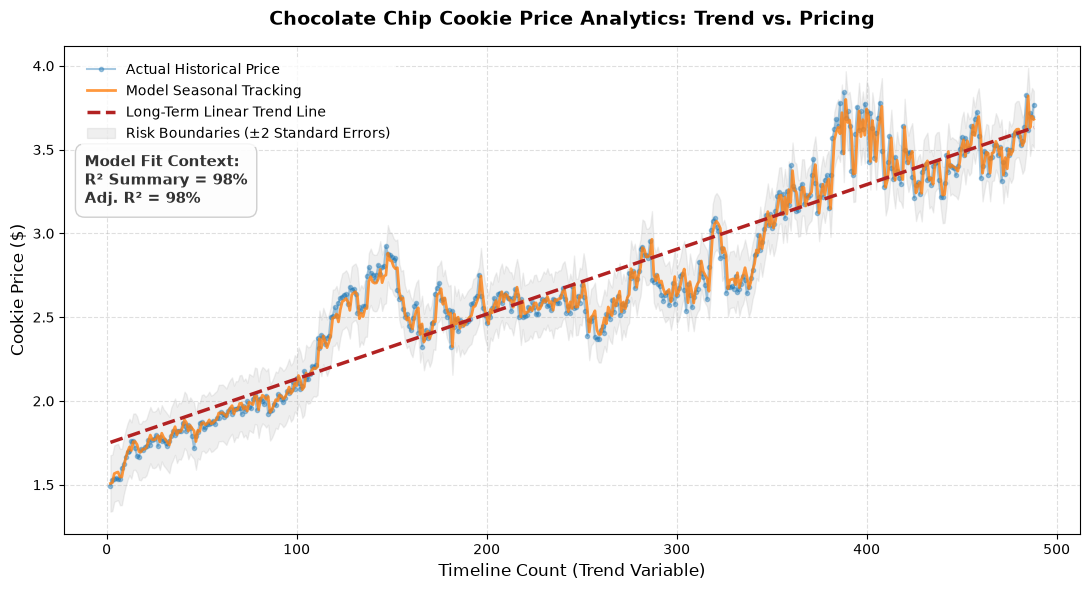

In [8]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

# 1. Load your Excel file
df = pd.read_excel('Desktop/Practice/Mod2_Wk7_Forecasting.xlsx')

# Force every column header to be text, then strip accidental spaces
df.columns = df.columns.astype(str).str.strip()

# Dynamic Search for the Cookie Column
cookie_col = [col for col in df.columns if 'Chocolate' in col][0]

# 2. Engineer your features
df['Trend'] = range(1, len(df) + 1)
df['Lagged_Price'] = df[cookie_col].shift(1)  

# 3. Clean the rows
features = [cookie_col, 'Trend', 'Q1', 'Q2', 'Q3', 'Lagged_Price']
df_clean = df[features].dropna().copy()

# 4. Define your Y and X variables and fit the model
Y = df_clean[cookie_col]
X = df_clean[['Trend', 'Q1', 'Q2', 'Q3', 'Lagged_Price']]
X = sm.add_constant(X)
model = sm.OLS(Y, X).fit()

# 5. Calculate the straight Long-Term Linear Trend Line
trend_fit = np.polyfit(df_clean['Trend'], df_clean[cookie_col], 1)
df_clean['Linear_Trendline'] = trend_fit[0] * df_clean['Trend'] + trend_fit[1]

# 6. Grab the model's seasonal predictions
df_clean['Fitted'] = model.fittedvalues

# 7. Initialize the plotting space
fig, ax = plt.subplots(figsize=(11, 6))

# Plot the REAL historical cookie prices
ax.plot(df_clean['Trend'], df_clean[cookie_col], 
        label='Actual Historical Price', color='#1f77b4', alpha=0.4, marker='o', markersize=3)

# Plot the MODEL'S seasonal tracking path
ax.plot(df_clean['Trend'], df_clean['Fitted'], 
        label='Model Seasonal Tracking', color='#ff7f0e', linewidth=2, alpha=0.8)

# Plot the clean, straight Long-Term Linear Trend Line
ax.plot(df_clean['Trend'], df_clean['Linear_Trendline'], 
        label='Long-Term Linear Trend Line', color='#b22222', linestyle='--', linewidth=2.5)

# Extract Standard Error and shade the 95% Confidence Risk Zone (±2 SE)
standard_error = model.mse_resid**0.5
ax.fill_between(df_clean['Trend'], 
                df_clean['Fitted'] - (2 * standard_error), 
                df_clean['Fitted'] + (2 * standard_error), 
                color='gray', alpha=0.12, label='Risk Boundaries (±2 Standard Errors)')

# 8. NEW: Overlay the R-squared percentage in a professional text box
# This extracts the R2 value and rounds it to a whole percentage string
r2_text = f"Model Fit Context:\nR² Summary = {model.rsquared * 100:.0f}%\nAdj. R² = {model.rsquared_adj * 100:.0f}%"

# transform=ax.transAxes treats (0,0) as bottom-left and (1,1) as top-right of the graph
ax.text(0.02, 0.78, r2_text, transform=ax.transAxes, fontsize=11,
        fontweight='bold', color='#333333', verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#fdfdfd', edgecolor='#cccccc', alpha=0.95))

# Add executive-level styling and labels
ax.set_title('Chocolate Chip Cookie Price Analytics: Trend vs. Pricing', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Timeline Count (Trend Variable)', fontsize=12)
ax.set_ylabel('Cookie Price ($)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)

# Shift legend down slightly to give the text box breathing room
ax.legend(loc='upper left', bbox_to_anchor=(0.01, 0.99), frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()